<a href="https://colab.research.google.com/github/LoraShima/Exercises_CV_2026/blob/main/Exercise3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MODULE 3: IMAGE CLASSIFICATION

Christian Mata, PhD

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1.Load image

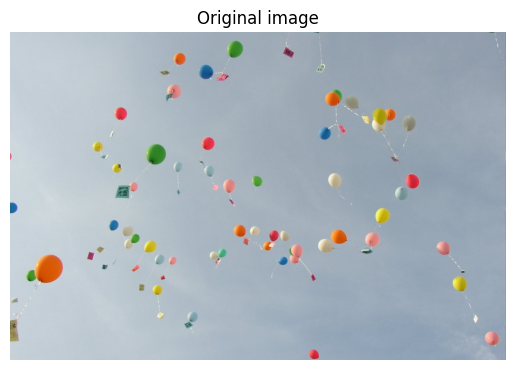

In [3]:
import matplotlib.pyplot as plt
from skimage import io

# Load image from Google Drive
I = io.imread('/content/drive/MyDrive/CV/baloons.jpg')

# Show image
plt.imshow(I)
plt.title("Original image")
plt.axis('off')
plt.show()

2.Convert from RGB to grayscale

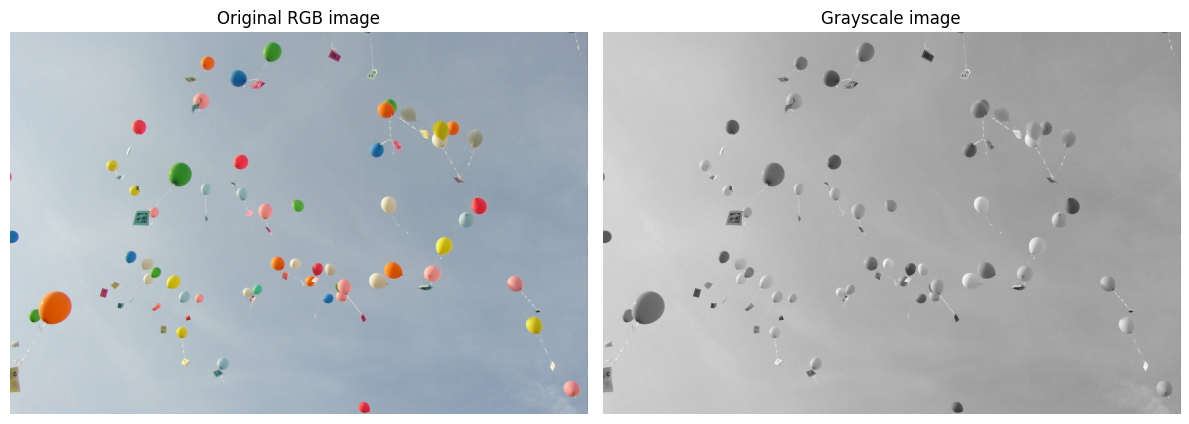

In [4]:
from skimage import color

# Convert RGB image to grayscale
IG = color.rgb2gray(I)

# Show original and grayscale images
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(I)
ax[0].set_title('Original RGB image')
ax[0].axis('off')

ax[1].imshow(IG, cmap='gray')
ax[1].set_title('Grayscale image')
ax[1].axis('off')

plt.tight_layout()
plt.show()

3. Gamma correction with $\gamma=0.5$

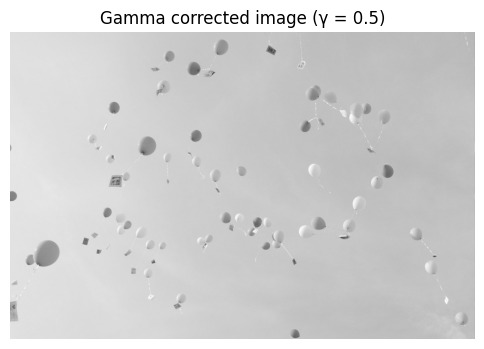

In [5]:
from skimage import exposure

# Apply gamma correction with gamma = 0.5
IG_gamma = exposure.adjust_gamma(IG, gamma=0.5)

# Show gamma corrected image
plt.figure(figsize=(6,6))

plt.imshow(IG_gamma, cmap='gray')
plt.title('Gamma corrected image (γ = 0.5)')
plt.axis('off')

plt.show()

4. Otsu threshold from grayscale (non gamma corrected)

In [8]:
from skimage.filters import threshold_otsu

# Compute Otsu threshold
thresh = threshold_otsu(IG)

print(thresh)

0.7109542057291668


5. Apply Otsu's threhold to gamma-corrected image

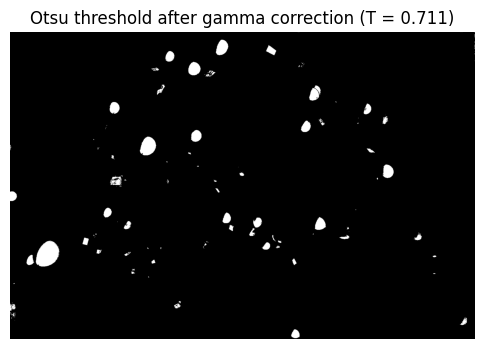

In [12]:
# Apply threshold
binary_gamma = IG_gamma < thresh

# Show thresholded gamma-corrected image
plt.figure(figsize=(6,6))

plt.imshow(binary_gamma, cmap='gray')
plt.title(f'Otsu threshold after gamma correction (T = {thresh:.3f})')
plt.axis('off')

plt.show()

6. label the objects

number of regions is 177


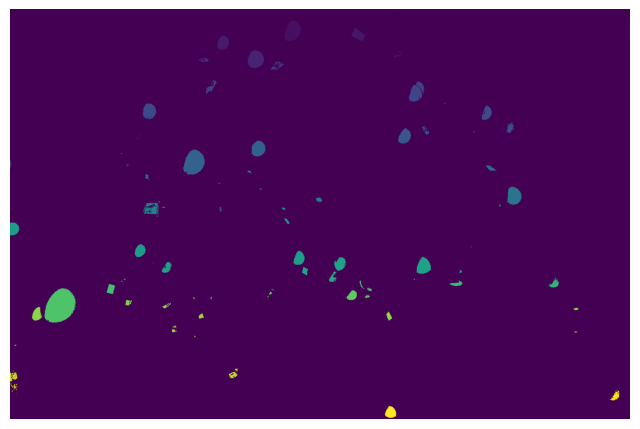

In [14]:
from skimage.measure import label

# Label connected regions
label_image, nregions = label(binary_gamma, return_num=True)

print('number of regions is', nregions)

# Show labelled regions
plt.figure(figsize=(8,8))

plt.imshow(label_image, cmap='viridis')
plt.axis('off')

plt.show()

7. Extract regional properties (Area and eccentricity)


In [16]:
from skimage.measure import regionprops
import numpy as np

# Extract regional properties
props = regionprops(label_image)

# Create arrays to store area and eccentricity
area = np.zeros(nregions)
eccentricity = np.zeros(nregions)

for i in range(nregions):
    area[i] = props[i].area
    eccentricity[i] = props[i].eccentricity

# Print results
for i in range(nregions):
    print(f"Region {i+1}: Area = {area[i]}, Eccentricity = {eccentricity[i]}")

Region 1: Area = 28.0, Eccentricity = 0.9640914074512694
Region 2: Area = 39.0, Eccentricity = 0.983701726382264
Region 3: Area = 4.0, Eccentricity = 1.0
Region 4: Area = 6.0, Eccentricity = 1.0
Region 5: Area = 3.0, Eccentricity = 1.0
Region 6: Area = 1.0, Eccentricity = 0.0
Region 7: Area = 1622.0, Eccentricity = 0.7357102032039212
Region 8: Area = 4.0, Eccentricity = 1.0
Region 9: Area = 1.0, Eccentricity = 0.0
Region 10: Area = 9.0, Eccentricity = 1.0
Region 11: Area = 646.0, Eccentricity = 0.7771320471083432
Region 12: Area = 5.0, Eccentricity = 1.0
Region 13: Area = 857.0, Eccentricity = 0.6091366429894123
Region 14: Area = 1.0, Eccentricity = 0.0
Region 15: Area = 3.0, Eccentricity = 1.0
Region 16: Area = 1.0, Eccentricity = 0.0
Region 17: Area = 1487.0, Eccentricity = 0.4434373094514306
Region 18: Area = 2.0, Eccentricity = 1.0
Region 19: Area = 1.0, Eccentricity = 0.0
Region 20: Area = 6.0, Eccentricity = 0.7905694150420949
Region 21: Area = 5.0, Eccentricity = 0.8846517369293

Show the sccaterplot the features

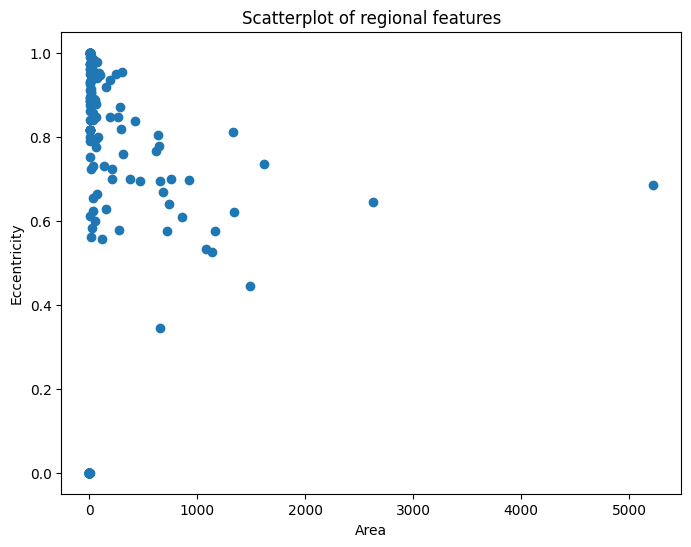

In [18]:
# Scatterplot of regional features
plt.figure(figsize=(8,6))

plt.scatter(area, eccentricity)

plt.xlabel('Area')
plt.ylabel('Eccentricity')
plt.title('Scatterplot of regional features')

plt.show()

8. Find balloons as objects with area higher than 500 and eccentricity lower than 0.8

In [19]:
# Find balloons based on area and eccentricity conditions
balloons = np.where((area > 500) & (eccentricity < 0.8))[0]

print("Balloon regions:", balloons + 1)
print("Number of balloons:", len(balloons))

Balloon regions: [  7  11  13  17  40  47  55  56  68  77  97  98 100 101 102 128 146 177]
Number of balloons: 18


9. Plot the baloons

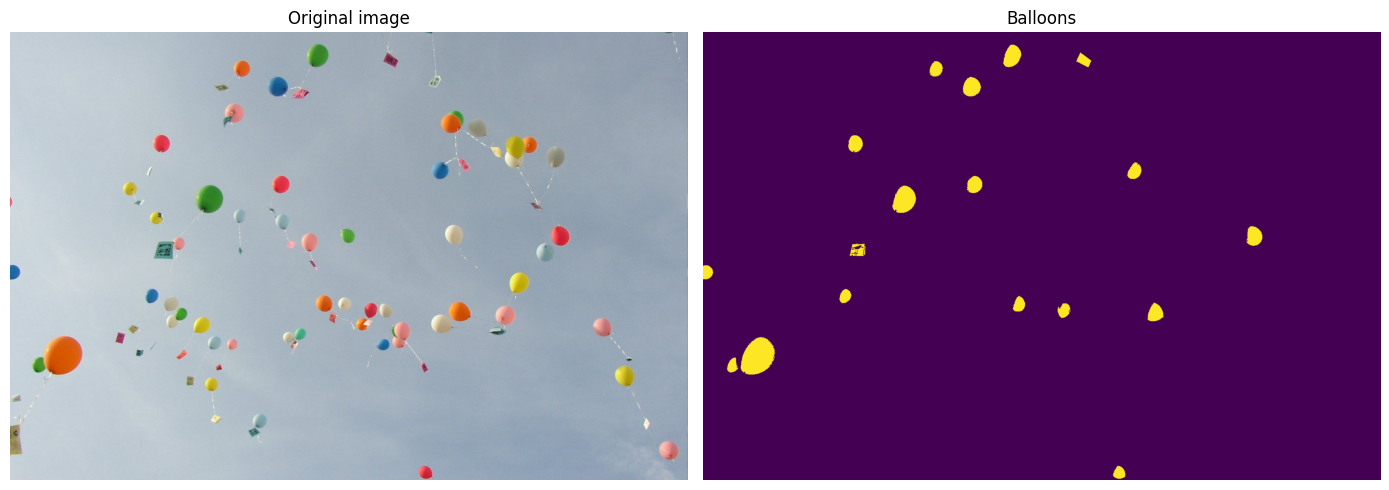

In [20]:
# Create empty image
balloons_image = np.zeros_like(label_image)

# Keep only balloon regions
for i in balloons:
    balloons_image[label_image == (i + 1)] = 1

# Plot balloons
fig, ax = plt.subplots(1, 2, figsize=(14,6))

ax[0].imshow(I)
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(balloons_image, cmap='viridis')
ax[1].set_title('Balloons')
ax[1].axis('off')

plt.tight_layout()
plt.show()